# Single cell RNA+ATAC tutorial (in python)

## Introduction

The same single-cell RNA + ATAC analysis workflow can also be performed in Python. While the Python bioinformatics ecosystem is relatively newer than the R ecosystem, it has been developing rapidly, driven by the increasing scale of datasets and its strong compatibility with machine learning and deep learning approaches.

A range of Python tools exist for scATAC-seq analysis, with different levels of stability and long-term support. In this tutorial, we will focus on [SnapATAC2](https://scverse.org/SnapATAC2/index.html) because it fits well within the [scverse](https://scverse.org/packages/) ecosystem.

In [2]:
# very helpful commands!
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
!which pip # take a look at which pip is being used, to make sure it's the one in the current environment

/work/upzenk/miniconda3/envs/scMultiome/bin/pip


In [4]:
# set up 
!pip install -r requirements.txt

**An important note**:

If you failed to instalol snapatac2, the [Nightly build](https://scverse.org/SnapATAC2/install.html) could be a workaround. 

## Read in the data

In [5]:
# import libraries
import scanpy as sc
import snapatac2 as snap

/work/upzenk/miniconda3/envs/scMultiome/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# read in the data from 10x output folder
adata = snap.read_10x_mtx(
    "data_small/filtered_feature_bc_matrix-small/",
)
adata

AnnData object with n_obs × n_vars = 8000 × 137688
    var: 1, 2

In [7]:
# Have a look 
adata.var.head()

,1,2
index,,
MIR1302-2HG,MIR1302-2HG,Gene Expression
FAM138A,FAM138A,Gene Expression
OR4F5,OR4F5,Gene Expression
AL627309.1,AL627309.1,Gene Expression
AL627309.3,AL627309.3,Gene Expression


In [8]:
# rename the columns of the var dataframe for easier access
adata.var.columns = ["feature", "feature_types"]
adata.var.head()

,feature,feature_types
index,,
MIR1302-2HG,MIR1302-2HG,Gene Expression
FAM138A,FAM138A,Gene Expression
OR4F5,OR4F5,Gene Expression
AL627309.1,AL627309.1,Gene Expression
AL627309.3,AL627309.3,Gene Expression


In [9]:
# use the cell barcode suffix to add the batch information to the obs dataframe
adata.obs["batch"] = adata.obs_names.str.split("-").str[-1]
# match batch 1 -> 'WT', batch 2 -> 'KO1', batch 3 -> 'KO2'
adata.obs["sample"] = adata.obs["batch"].map({"1": "WT", "2": "KO1", "3": "KO2"})
adata.obs.head()

,batch,sample
index,,
GTTCCCAGTACGCGCA-3,3,KO2
TCGTTTCCACAAAGAC-3,3,KO2
CGAGGTGAGTACTGGT-2,2,KO1
AATCCTAAGGCGCATC-1,1,WT
GCTTAACAGGAGCAAC-3,3,KO2


In [10]:
# split the data into RNA and ATAC
rna = adata[:, adata.var["feature_types"] == "Gene Expression"]
rna

View of AnnData object with n_obs × n_vars = 8000 × 36601
    obs: 'batch', 'sample'
    var: 'feature', 'feature_types'

In [11]:
atac = adata[:, adata.var["feature_types"] == "Peaks"]
atac 

View of AnnData object with n_obs × n_vars = 8000 × 101087
    obs: 'batch', 'sample'
    var: 'feature', 'feature_types'

In [12]:
# sanity check: cell barcodes should be the same in both datasets   
assert all(rna.obs_names == atac.obs_names)

### Have a peek into the data format

In [13]:
# RNA: check the first few GenesxCells as a dataframe
import pandas as pd
pd.DataFrame(rna.X[:5, :10].toarray(), index=rna.obs_names[:5], columns=rna.var_names[:10])

index,MIR1302-2HG,FAM138A,OR4F5,AL627309.1,AL627309.3,AL627309.2,AL627309.5,AL627309.4,AP006222.2,AL732372.1
index,,,,,,,,,,
GTTCCCAGTACGCGCA-3,0,0,0,0,0,0,0,0,0,0
TCGTTTCCACAAAGAC-3,0,0,0,0,0,0,0,0,0,0
CGAGGTGAGTACTGGT-2,0,0,0,0,0,0,0,0,0,0
AATCCTAAGGCGCATC-1,0,0,0,0,0,0,0,0,0,0
GCTTAACAGGAGCAAC-3,0,0,0,0,0,0,0,0,0,0


In [14]:
# the same for ATAC, but here we have Peaks instead of Genes
pd.DataFrame(atac.X[:5, :10].toarray(), index=atac.obs_names[:5], columns=atac.var_names[:10])

index,chr1:633580-634476,chr1:778300-779211,chr1:827064-827921,chr1:845429-846291,chr1:869481-870391,chr1:904404-905218,chr1:912637-913483,chr1:920785-921667,chr1:923439-924341,chr1:925442-925976
index,,,,,,,,,,
GTTCCCAGTACGCGCA-3,0,0,2,0,0,0,0,0,0,0
TCGTTTCCACAAAGAC-3,0,6,0,0,0,4,0,0,0,0
CGAGGTGAGTACTGGT-2,0,3,0,0,2,1,0,0,0,0
AATCCTAAGGCGCATC-1,0,2,0,0,0,0,0,0,0,0
GCTTAACAGGAGCAAC-3,0,4,2,0,0,0,2,0,0,0


## Part 1: Quality control

### RNA assay

We start with the gene expression dataset. We start with the gene expression data.
Standard RNA quality control includes:
* Percentage of mitochondrial genes
* Number of detected genes per cell (n_genes_by_counts)
* Total counts per cell (total_counts)

Cells with:
* very low gene counts (empty droplets),
* extremely high counts (doublets), or
* high mitochondrial percentage (stressed/dying cells)
are typically removed.

/tmp/ipykernel_3218096/815340680.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  rna.var['mt'] = rna.var_names.str.startswith("MT-")
... storing 'batch' as categorical
... storing 'sample' as categorical
... storing 'feature_types' as categorical


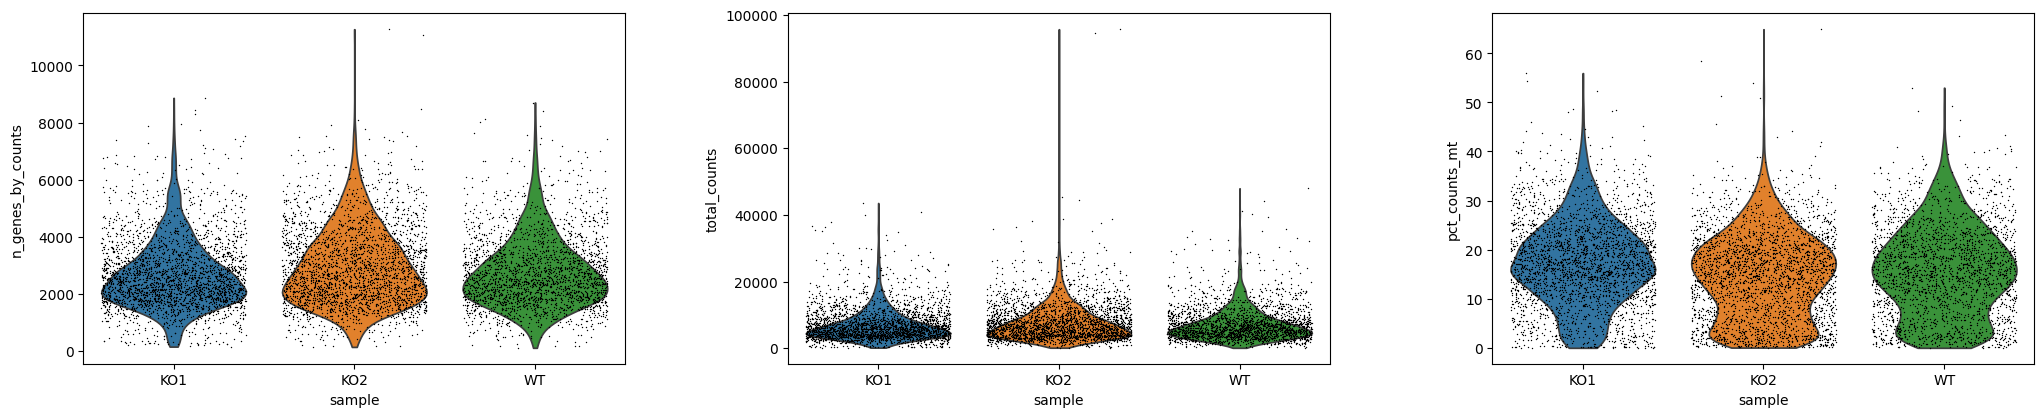

In [15]:
rna.var['mt'] = rna.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(rna, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
sc.pl.violin(rna, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], jitter=0.4, multi_panel=True, groupby="sample")

In [16]:
# filter out low quality cells
rna = rna[rna.obs["n_genes_by_counts"] > 500, :]
rna = rna[rna.obs["n_genes_by_counts"] < 6000, :]
rna = rna[rna.obs["pct_counts_mt"] < 40, :]
rna

View of AnnData object with n_obs × n_vars = 7724 × 36601
    obs: 'batch', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'feature', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'sample_colors'

In [17]:
sc.pp.filter_cells(rna, min_genes=100)
sc.pp.filter_genes(rna, min_cells=3)
rna

/work/upzenk/miniconda3/envs/scMultiome/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:161: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


AnnData object with n_obs × n_vars = 7724 × 26885
    obs: 'batch', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'feature', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'sample_colors'

### ATAC assay

#### Step 0: Propagate RNA filtering results
Since this is multiome data, RNA and ATAC share the same cell barcodes. We therefore propagate the RNA QC filtering to the ATAC dataset.

In [18]:
# select the cells that passed the RNA QC in the ATAC dataset as well
atac = atac[rna.obs_names, :]
atac

View of AnnData object with n_obs × n_vars = 7724 × 101087
    obs: 'batch', 'sample'
    var: 'feature', 'feature_types'

#### Step 1: Basic matrix-level QC

Here we assess:
* Number of accessible peaks per cell
* Total accessibility counts per cell

/work/upzenk/miniconda3/envs/scMultiome/lib/python3.13/site-packages/scanpy/preprocessing/_qc.py:125: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_metrics.columns] = obs_metrics
... storing 'batch' as categorical
... storing 'sample' as categorical
... storing 'feature_types' as categorical


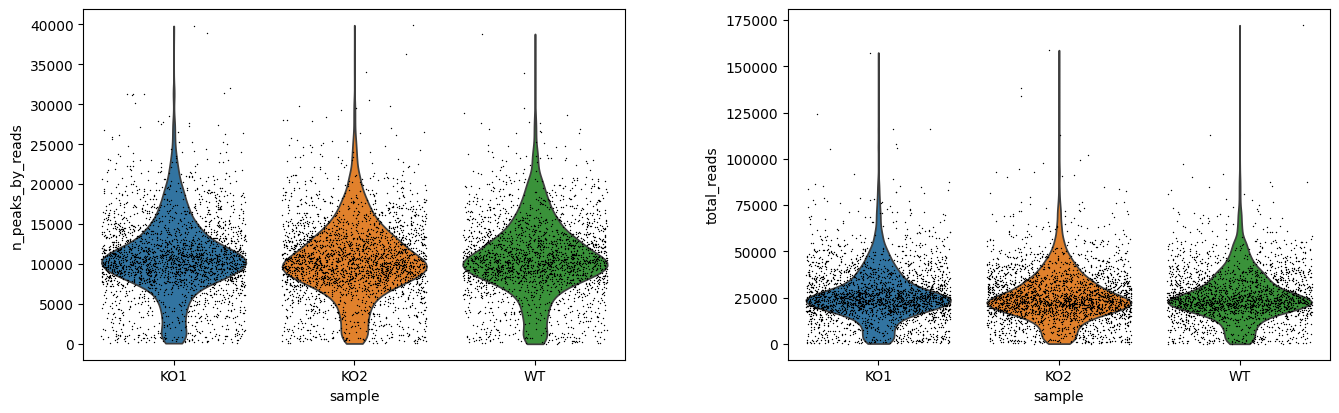

In [19]:
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True, var_type='peaks', expr_type='reads')
sc.pl.violin(atac, ["n_peaks_by_reads", "total_reads"], jitter=0.4, multi_panel=True, groupby="sample")

In [20]:
# filter out low quality cells
atac = atac[atac.obs["n_peaks_by_reads"] > 1000, :]
atac = atac[atac.obs["n_peaks_by_reads"] < 25000, :]
atac = atac[atac.obs["total_reads"] < 100000, :]
atac

View of AnnData object with n_obs × n_vars = 7451 × 101087
    obs: 'batch', 'sample', 'n_peaks_by_reads', 'total_reads'
    var: 'feature', 'feature_types', 'n_cells_by_reads', 'mean_reads', 'pct_dropout_by_reads', 'total_reads'
    uns: 'sample_colors'

In [21]:
# optional: filter out low quality peaks (e.g. peaks that are present in less than x cells)
min_cells = 0.05*rna.n_obs 
atac = atac[:, (atac.X > 0).sum(axis=0) > min_cells]
min_reads = 100
atac = atac[:, atac.X.sum(axis=0) > min_reads]
atac

View of AnnData object with n_obs × n_vars = 7451 × 52668
    obs: 'batch', 'sample', 'n_peaks_by_reads', 'total_reads'
    var: 'feature', 'feature_types', 'n_cells_by_reads', 'mean_reads', 'pct_dropout_by_reads', 'total_reads'
    uns: 'sample_colors'

In [22]:
# optional: keep only standard chromosomes (e.g. chr1, chr2, ..., chrX, chrY) in the ATAC dataset
standard_chromosomes = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
atac = atac[:, atac.var_names.str.split(":").str[0].isin(standard_chromosomes)]
atac

View of AnnData object with n_obs × n_vars = 7451 × 52651
    obs: 'batch', 'sample', 'n_peaks_by_reads', 'total_reads'
    var: 'feature', 'feature_types', 'n_cells_by_reads', 'mean_reads', 'pct_dropout_by_reads', 'total_reads'
    uns: 'sample_colors'

#### Step 2: Fragment-level QC

ATAC data can be represented as a sparse count matrix, similar to RNA—although it is typically much larger and even sparser. However, unlike RNA-seq, the peak count matrix is only a summarized representation of the underlying data.

Because ATAC-seq measures chromatin accessibility at genomic intervals, important quality metrics depend on the original fragment coordinates. Therefore, proper ATAC quality control requires fragment-level information.

Common fragment-level QC metrics include:
* TSS enrichment score (signal enrichment around transcription start sites)
* Nucleosome signal (fragment length periodicity)
* Fraction of reads in peaks (FRiP)
* Total fragments per cell

These metrics cannot be computed from the peak matrix alone and require the `fragments.tsv.gz` file.

And here is why we need the `snapATAC2` package.


In [23]:
# import the fragment file (takes a few minutes)
frag = snap.pp.import_fragments("data_small/atac_fragments.tsv.gz",
                                chrom_sizes=snap.genome.hg38,
                                whitelist=atac.obs_names.tolist(),
                                sorted_by_barcode=False)

In [24]:
frag

AnnData object with n_obs × n_vars = 7451 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito'
    uns: 'reference_sequences'
    obsm: 'fragment_paired'

**What is this frag file?**

The `frag` object is an AnnData representation of the raw fragment file (fragments.tsv.gz).

While the `atac` object contains a summarized cell × peak count matrix (as provided by 10x), the fragment file stores the original genomic coordinates of each accessibility event.

The peak matrix is therefore a derived representation of the fragment data.

In this tutorial, we primarily use the peak matrix (`atac`) for downstream analysis to stay consistent with our R workflow. However, we use the fragment-level object (`frag`) to compute fragment-based QC metrics and perform additional filtering.

##### Nucleosome pattern

The typical fragment size distribution in ATAC-seq data will exhibit 'nucleosome' pattern, i.e a mono-nucleosome peak at around 147 - 200bp

2026-04-09 14:48:06 - INFO - Computing fragment size distribution...
2026-04-09 14:48:13 - INFO - Chromium init'ed with kwargs {}
2026-04-09 14:48:13 - INFO - Found chromium path: /work/upzenk/miniconda3/envs/scMultiome/lib/python3.13/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
2026-04-09 14:48:13 - INFO - Temp directory created: /tmp/tmpkl36a0kz.
2026-04-09 14:48:13 - INFO - Opening browser.
2026-04-09 14:48:13 - INFO - Temp directory created: /tmp/tmpqzjb6zmd.
2026-04-09 14:48:13 - INFO - Temporary directory at: /tmp/tmpqzjb6zmd
2026-04-09 14:48:22 - INFO - Conforming 1 to file:///tmp/tmpkl36a0kz/index.html
2026-04-09 14:48:22 - INFO - Waiting on all navigates
2026-04-09 14:48:24 - INFO - All navigates done, putting them all in queue.
2026-04-09 14:48:24 - INFO - Getting tab from queue (has 1)
2026-04-09 14:48:24 - INFO - Got ADE2
2026-04-09 14:48:24 - INFO - Processing fig.png
2026-04-09 14:48:24 - INFO - Sending big command for fig.png.
2026-04-09 14:48:24 - I

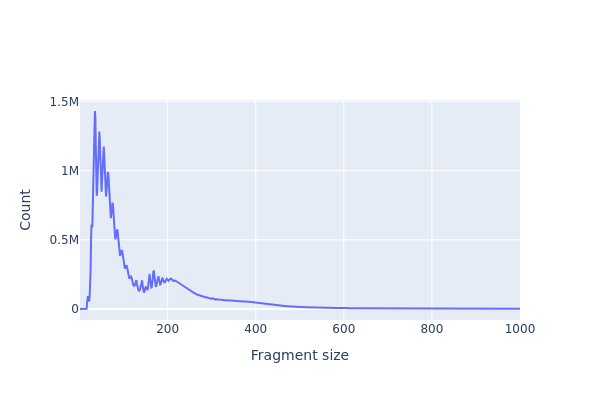

In [25]:
# plot the fragment size distribution to check for the expected periodicity
snap.pl.frag_size_distr(frag, interactive=False)

##### TSS enrichment

From the official [SnapATAC tutorial](https://scverse.org/SnapATAC2/tutorials/pbmc.html#Preprocessing):

 "TSSe in ATAC-seq data implies that there is an increased accessibility or fragmentation of chromatin around the transcription start sites of genes. This is often indicative of open and accessible promoter regions, which are typically devoid of nucleosomes and are involved in active gene transcription."

In [26]:
snap.metrics.tsse(frag, snap.genome.hg38)
frag

AnnData object with n_obs × n_vars = 7451 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

2026-04-09 14:48:33 - INFO - TemporaryDirectory.cleanup() worked.
2026-04-09 14:48:33 - INFO - shutil.rmtree worked.
2026-04-09 14:48:37 - INFO - Chromium init'ed with kwargs {}
2026-04-09 14:48:37 - INFO - Found chromium path: /work/upzenk/miniconda3/envs/scMultiome/lib/python3.13/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
2026-04-09 14:48:37 - INFO - Temp directory created: /tmp/tmpxqmcsk1l.
2026-04-09 14:48:37 - INFO - Opening browser.
2026-04-09 14:48:37 - INFO - Temp directory created: /tmp/tmp339y9qkg.
2026-04-09 14:48:37 - INFO - Temporary directory at: /tmp/tmp339y9qkg
2026-04-09 14:48:37 - INFO - Conforming 1 to file:///tmp/tmpxqmcsk1l/index.html
2026-04-09 14:48:37 - INFO - Waiting on all navigates
2026-04-09 14:48:38 - INFO - All navigates done, putting them all in queue.
2026-04-09 14:48:38 - INFO - Getting tab from queue (has 1)
2026-04-09 14:48:38 - INFO - Got 24B5
2026-04-09 14:48:38 - INFO - Processing fig.png
2026-04-09 14:48:38 - INFO - Sending 

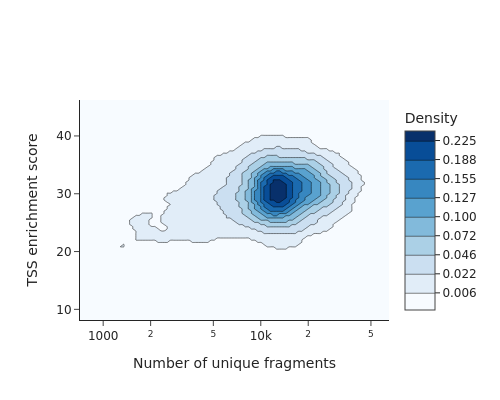

In [27]:
# check the histogram of TSS enrichment scores
snap.pl.tsse(frag, interactive=False)

In [28]:
snap.pp.filter_cells(frag, min_counts=3000, min_tsse=1, max_counts=50000)
frag

AnnData object with n_obs × n_vars = 7197 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

2026-04-09 14:48:42 - INFO - TemporaryDirectory.cleanup() worked.
2026-04-09 14:48:42 - INFO - shutil.rmtree worked.
2026-04-09 14:48:43 - INFO - Chromium init'ed with kwargs {}
2026-04-09 14:48:43 - INFO - Found chromium path: /work/upzenk/miniconda3/envs/scMultiome/lib/python3.13/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
2026-04-09 14:48:43 - INFO - Temp directory created: /tmp/tmp6df_mj0d.
2026-04-09 14:48:43 - INFO - Opening browser.
2026-04-09 14:48:43 - INFO - Temp directory created: /tmp/tmp_x8s7d3c.
2026-04-09 14:48:43 - INFO - Temporary directory at: /tmp/tmp_x8s7d3c
2026-04-09 14:48:43 - INFO - Conforming 1 to file:///tmp/tmp6df_mj0d/index.html
2026-04-09 14:48:43 - INFO - Waiting on all navigates
2026-04-09 14:48:44 - INFO - All navigates done, putting them all in queue.
2026-04-09 14:48:44 - INFO - Getting tab from queue (has 1)
2026-04-09 14:48:44 - INFO - Got 2DAA
2026-04-09 14:48:44 - INFO - Processing fig.png
2026-04-09 14:48:44 - INFO - Sending 

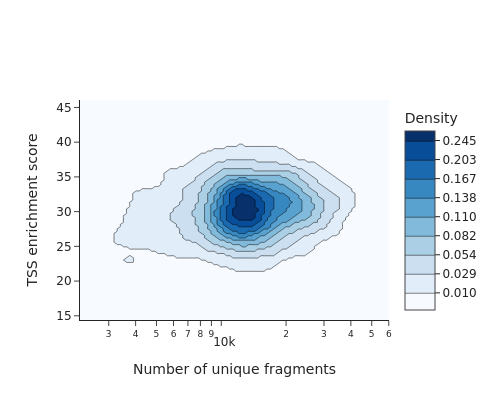

In [29]:
# have a look after filtering
snap.pl.tsse(frag, interactive=False)

In [30]:
# propogate the cell filtering to the RNA and ATAC datasets
rna = rna[frag.obs_names, :]
atac = atac[frag.obs_names, :]

In [31]:
# save the filtered datasets for later use
import os
os.makedirs("out", exist_ok=True)
rna.write("out/rna.h5ad")
atac.write("out/atac.h5ad")
frag.write("out/frag.h5ad")

## Part 2: Monomodal Data Analysis

After QC, we can process RNA and ATAC data separately.

### Gene expression analysis

The RNA modality follows a standard single-cell workflow: normalization, identification of highly variable genes, scaling, dimensionality reduction (PCA), and visualization (e.g., UMAP).

*NOTE:* We skip the scaling step here since it might create negative values, which is problematic for spectral decomposition needed later. 

In [32]:
# read in the filtered datasets (if you want to skip the previous steps)
# rna = sc.read_h5ad("out/rna.h5ad")
# atac = sc.read_h5ad("out/atac.h5ad")
# frag = sc.read_h5ad("out/frag.h5ad")

/tmp/ipykernel_3218096/307931080.py:2: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  rna.layers["counts"] = rna.X.copy()


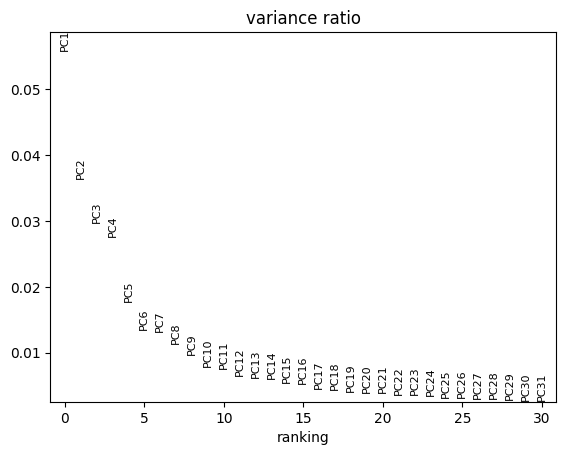

In [33]:
# Save raw counts
rna.layers["counts"] = rna.X.copy()

# Normalize and log-transform
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)

# Select highly variable genes
sc.pp.highly_variable_genes(rna, n_top_genes=3000)

# Run PCA
sc.pp.pca(rna, n_comps=50, svd_solver="arpack")

sc.pl.pca_variance_ratio(rna, n_pcs=30)

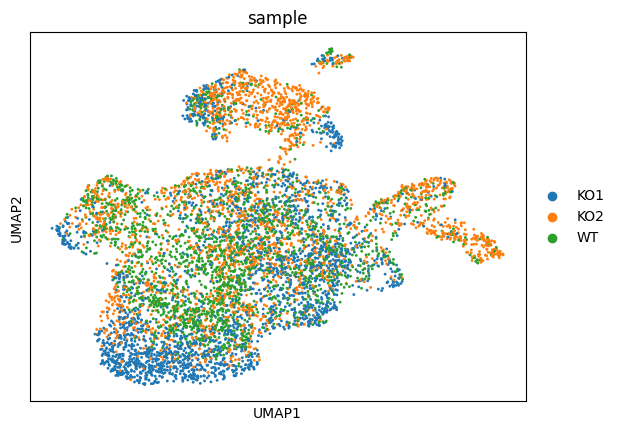

In [34]:
# Compute neighborhood graph
sc.pp.neighbors(rna, n_neighbors=15, n_pcs=15)

# UMAP embedding
sc.tl.umap(rna)

sc.pl.umap(rna, color=["sample"])

While the batch effects are relatively mild, we include an integration step for completeness and to demonstrate the workflow.


In [35]:
# use BBKNN for batch correction
sc.external.pp.bbknn(rna, batch_key="sample") 

/tmp/ipykernel_3218096/1463263790.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(rna, resolution=0.4)


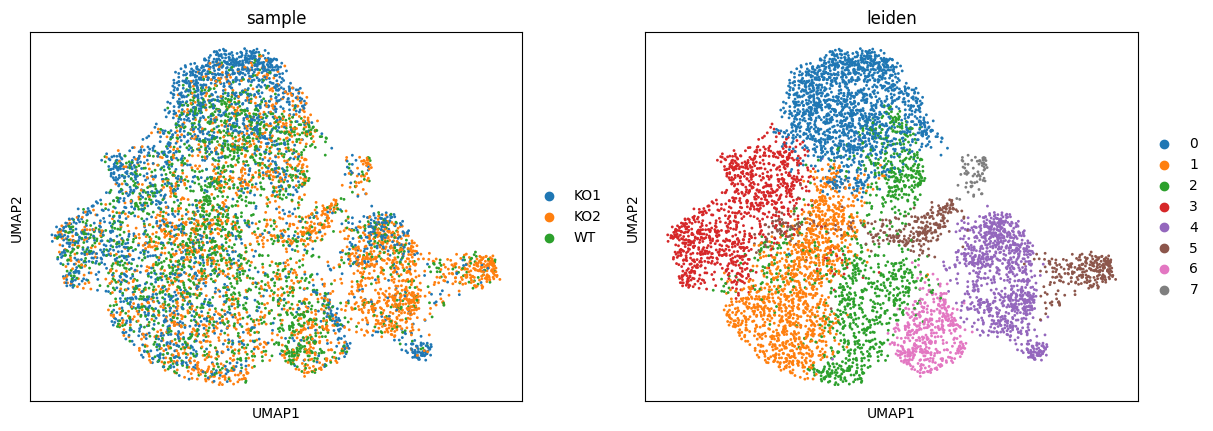

In [36]:
sc.tl.umap(rna)
# clustering
sc.tl.leiden(rna, resolution=0.4)
sc.pl.umap(rna, color=["sample","leiden"])

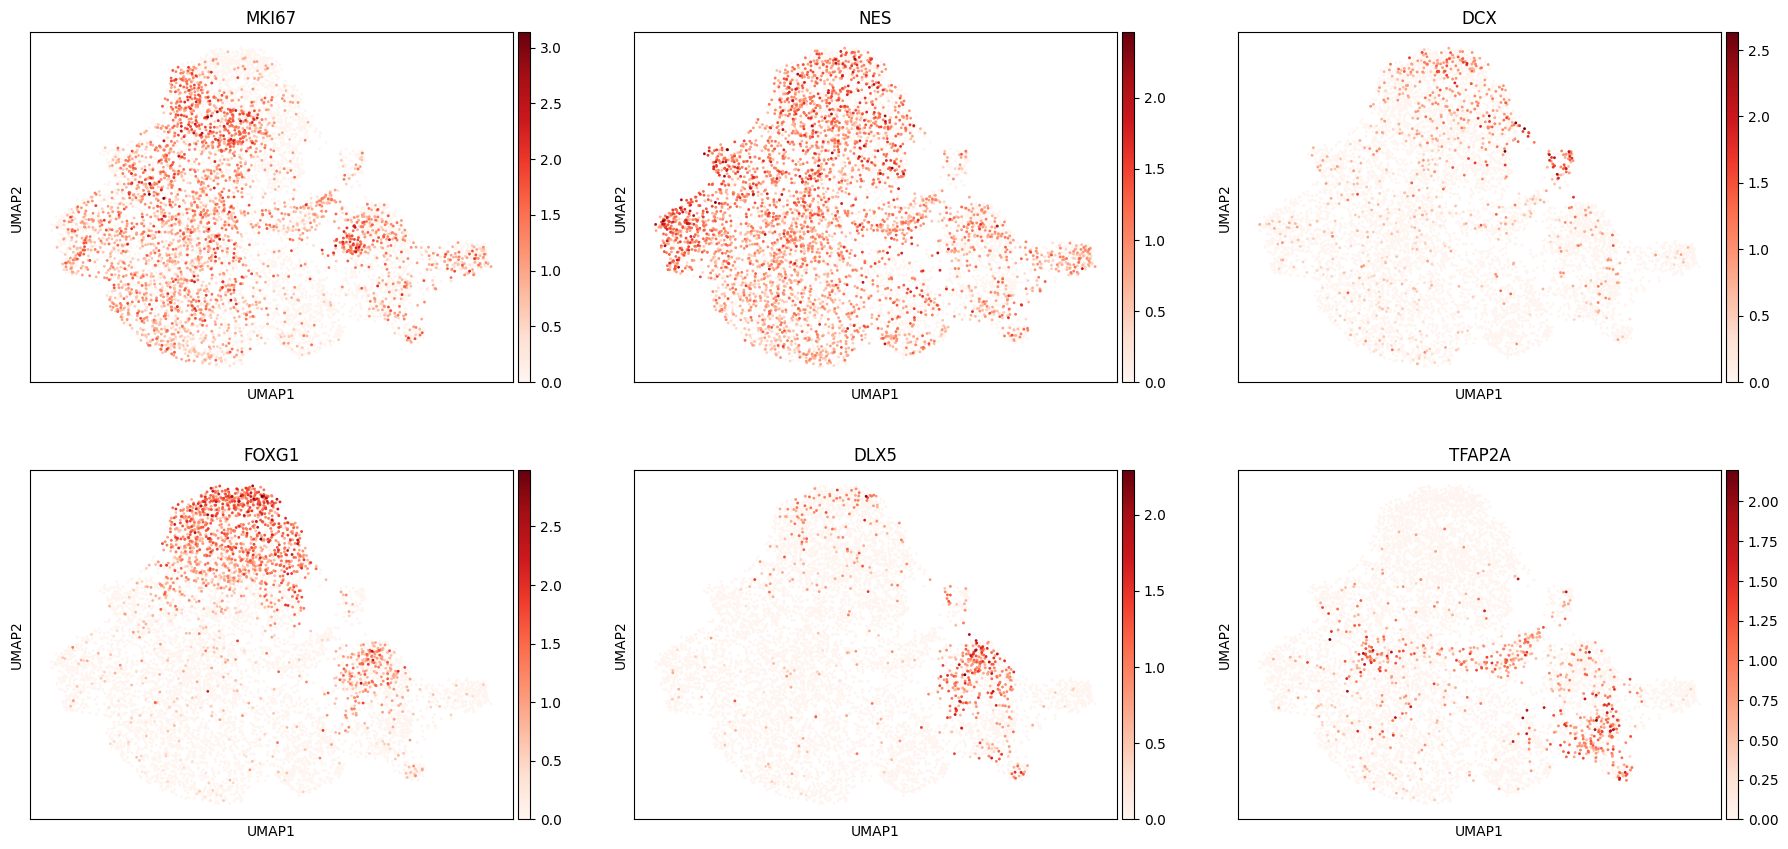

In [37]:
# can also plot some marker genes
marker_genes = ["MKI67","NES","DCX","FOXG1","DLX5","TFAP2A"]
sc.pl.umap(rna, color=marker_genes, ncols=3, cmap='Reds')

### Chromatin accessibility data

This part is largely inspired by this tutorial of [SnapATAC2](https://scverse.org/SnapATAC2/tutorials/pbmc.html#Dimension-reduction).

In [38]:
# select top features
snap.pp.select_features(atac, filter_lower_quantile=0.75)
atac

/work/upzenk/miniconda3/envs/scMultiome/lib/python3.13/site-packages/snapatac2/preprocessing/_basic.py:621: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['count'] = count
2026-04-09 14:50:43 - INFO - Selected 12900 features.


AnnData object with n_obs × n_vars = 7197 × 52651
    obs: 'batch', 'sample', 'n_peaks_by_reads', 'total_reads'
    var: 'feature', 'feature_types', 'n_cells_by_reads', 'mean_reads', 'pct_dropout_by_reads', 'total_reads', 'count', 'selected'
    uns: 'sample_colors'

To calculate the lower-dimensional representation of single-cell chromatin profiles, we employ spectral embedding for dimensionality reduction. 

In [39]:
# dimensionality reduction 
snap.tl.spectral(atac)

In [40]:
# have a look at the data - the results are stored in the obsm attribute 'X_spectral'
atac

AnnData object with n_obs × n_vars = 7197 × 52651
    obs: 'batch', 'sample', 'n_peaks_by_reads', 'total_reads'
    var: 'feature', 'feature_types', 'n_cells_by_reads', 'mean_reads', 'pct_dropout_by_reads', 'total_reads', 'count', 'selected'
    uns: 'sample_colors', 'spectral_eigenvalue'
    obsm: 'X_spectral'

/work/upzenk/miniconda3/envs/scMultiome/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_3218096/230863650.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(atac, resolution=0.4)


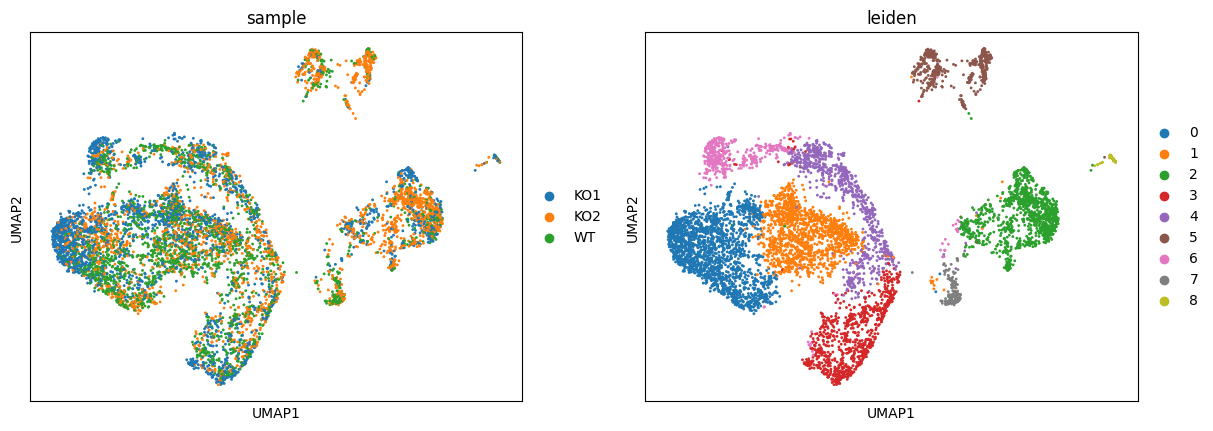

In [41]:
# umap embedding using snapatac2 (uses the spectral embedding as input)
snap.tl.umap(atac)
sc.pp.neighbors(atac, n_neighbors=15, n_pcs=30, use_rep="X_spectral")
sc.tl.leiden(atac, resolution=0.4)
sc.pl.umap(atac, color=["sample","leiden"])

#### Gene activity matrix

[SnapATAC](https://scverse.org/SnapATAC2/tutorials/pbmc.html#Cell-cluster-annotation) provides a function to link the chromatin accessibility with the genes nearby, and hence get the gene activity matrix.

In [42]:
gene_matrix = snap.pp.make_gene_matrix(frag, snap.genome.hg38)
gene_matrix

AnnData object with n_obs × n_vars = 7197 × 60606
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'

In some way, this the approximated GEX from atac profile - we can then treat it as 'RNA' data for the QC steps

In [43]:
sc.pp.filter_genes(gene_matrix, min_cells= 5)
sc.pp.normalize_total(gene_matrix)
sc.pp.log1p(gene_matrix)

In [44]:
# Copy over UMAP embedding from the ATAC dataset and the leiden clusters
gene_matrix.obsm["X_umap"] = atac.obsm["X_umap"]
gene_matrix.obs["leiden"] = atac.obs["leiden"]

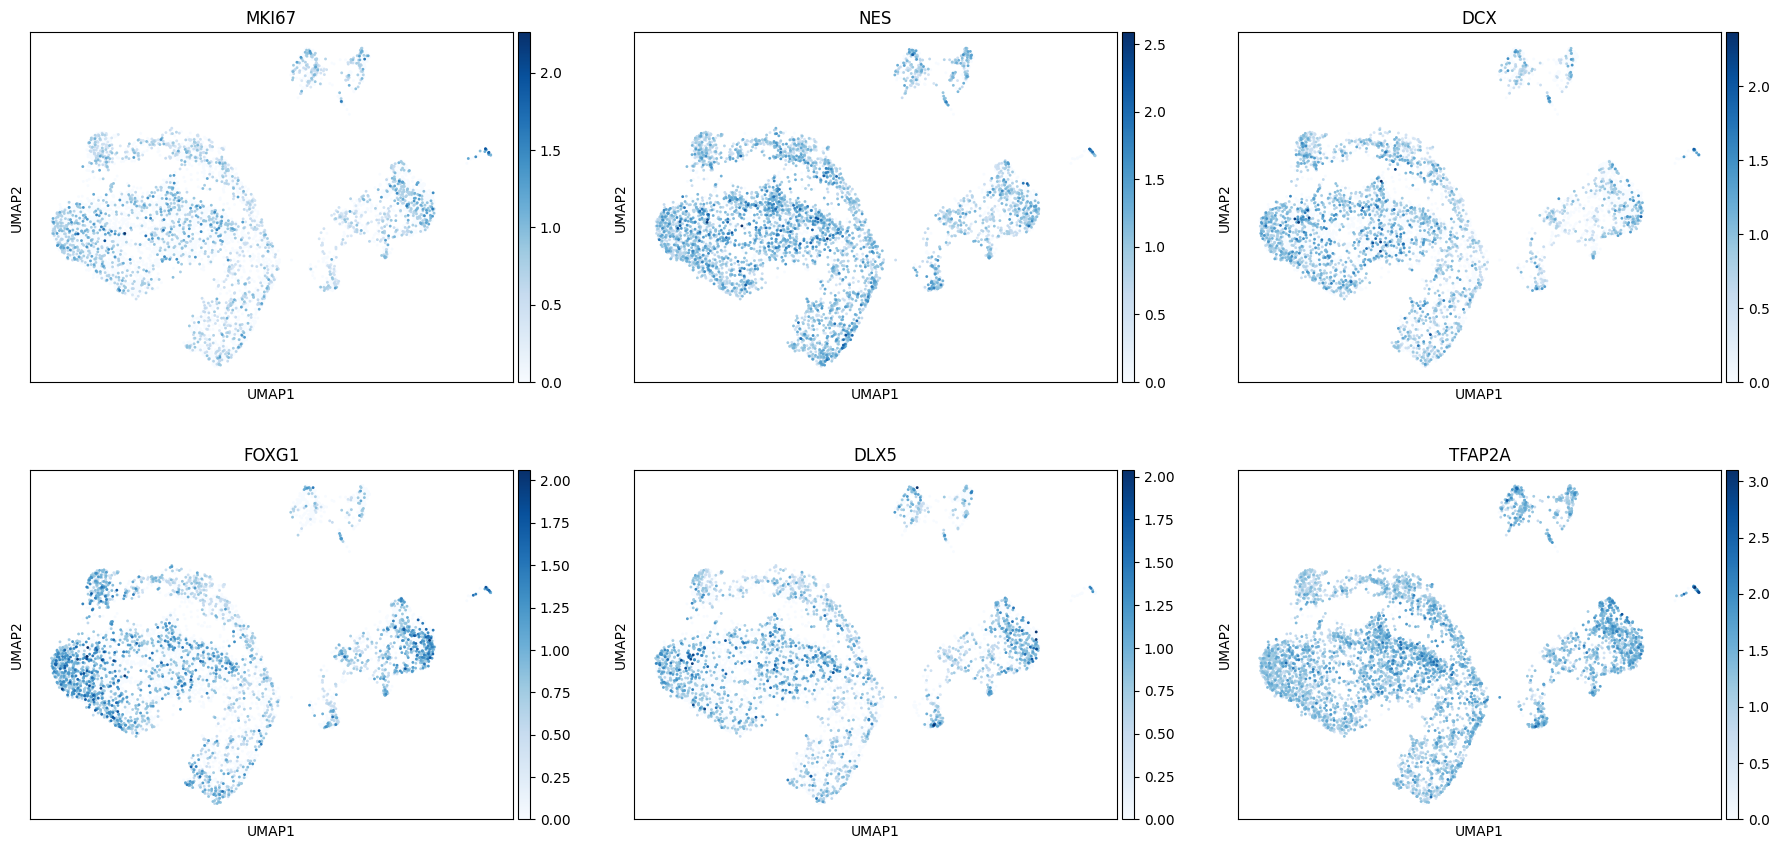

In [45]:
# Now we can plot the gene expression of some marker genes on the same UMAP embedding as the ATAC data
sc.pl.umap(gene_matrix, use_raw=False, color= marker_genes, ncols=3, cmap='Blues')

## Part 3: Multimodal data integration

### Step 1: Compute joint embedding space

This part follows https://scverse.org/SnapATAC2/tutorials/modality.html#Perform-joint-embedding

In [46]:
# sanity check: cell barcodes should be the same in all datasets
assert (rna.obs_names == atac.obs_names).all()

In [47]:
# convert .X to sparse matrix 
from scipy.sparse import csr_matrix
rna.X = csr_matrix(rna.X)
atac.X = csr_matrix(atac.X)

In [48]:
embedding = snap.tl.multi_spectral([rna, atac], features=None)[1]

2026-04-09 14:52:34 - INFO - Compute normalized views...


2026-04-09 14:53:38 - INFO - Compute embedding...


In [49]:
# have a look at the embedding
# should be of shape (n_cells, n_components), where n_components is the number of spectral components that were computed
embedding.shape

(7197, 30)

In [51]:
# add the joint embedding to the obsm attribute of both datasets (rna, atac and gene_matrix inferred from atac)
atac.obsm['X_joint'] = embedding
rna.obsm['X_joint'] = embedding
gene_matrix.obsm['X_joint'] = embedding
atac, rna, gene_matrix

(AnnData object with n_obs × n_vars = 7197 × 52651
     obs: 'batch', 'sample', 'n_peaks_by_reads', 'total_reads', 'leiden'
     var: 'feature', 'feature_types', 'n_cells_by_reads', 'mean_reads', 'pct_dropout_by_reads', 'total_reads', 'count', 'selected'
     uns: 'sample_colors', 'spectral_eigenvalue', 'neighbors', 'leiden', 'leiden_colors'
     obsm: 'X_spectral', 'X_umap', 'X_joint'
     obsp: 'distances', 'connectivities',
 AnnData object with n_obs × n_vars = 7197 × 26885
     obs: 'batch', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden'
     var: 'feature', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
     uns: 'sample_colors', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'
     obsm: 'X_pca', 'X_umap', 'X_joint'
     varm: 'PCs'
     layers: 'counts'
     obsp: 'distances', 'c

In [52]:
# calculate umap on the joint embedding
snap.tl.umap(atac, use_rep='X_joint', key_added='umap_joint')

/work/upzenk/miniconda3/envs/scMultiome/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


*NOTE* They should give the same results (because it's the same UMAP using the same spectral space). So in practice we can also compute one of them, then copy them over to to the obsm :)

In [54]:
# copy over the joint UMAP embedding to the other datasets
rna.obsm['X_umap_joint'] = atac.obsm['X_umap_joint']
gene_matrix.obsm['X_umap_joint'] = atac.obsm['X_umap_joint']

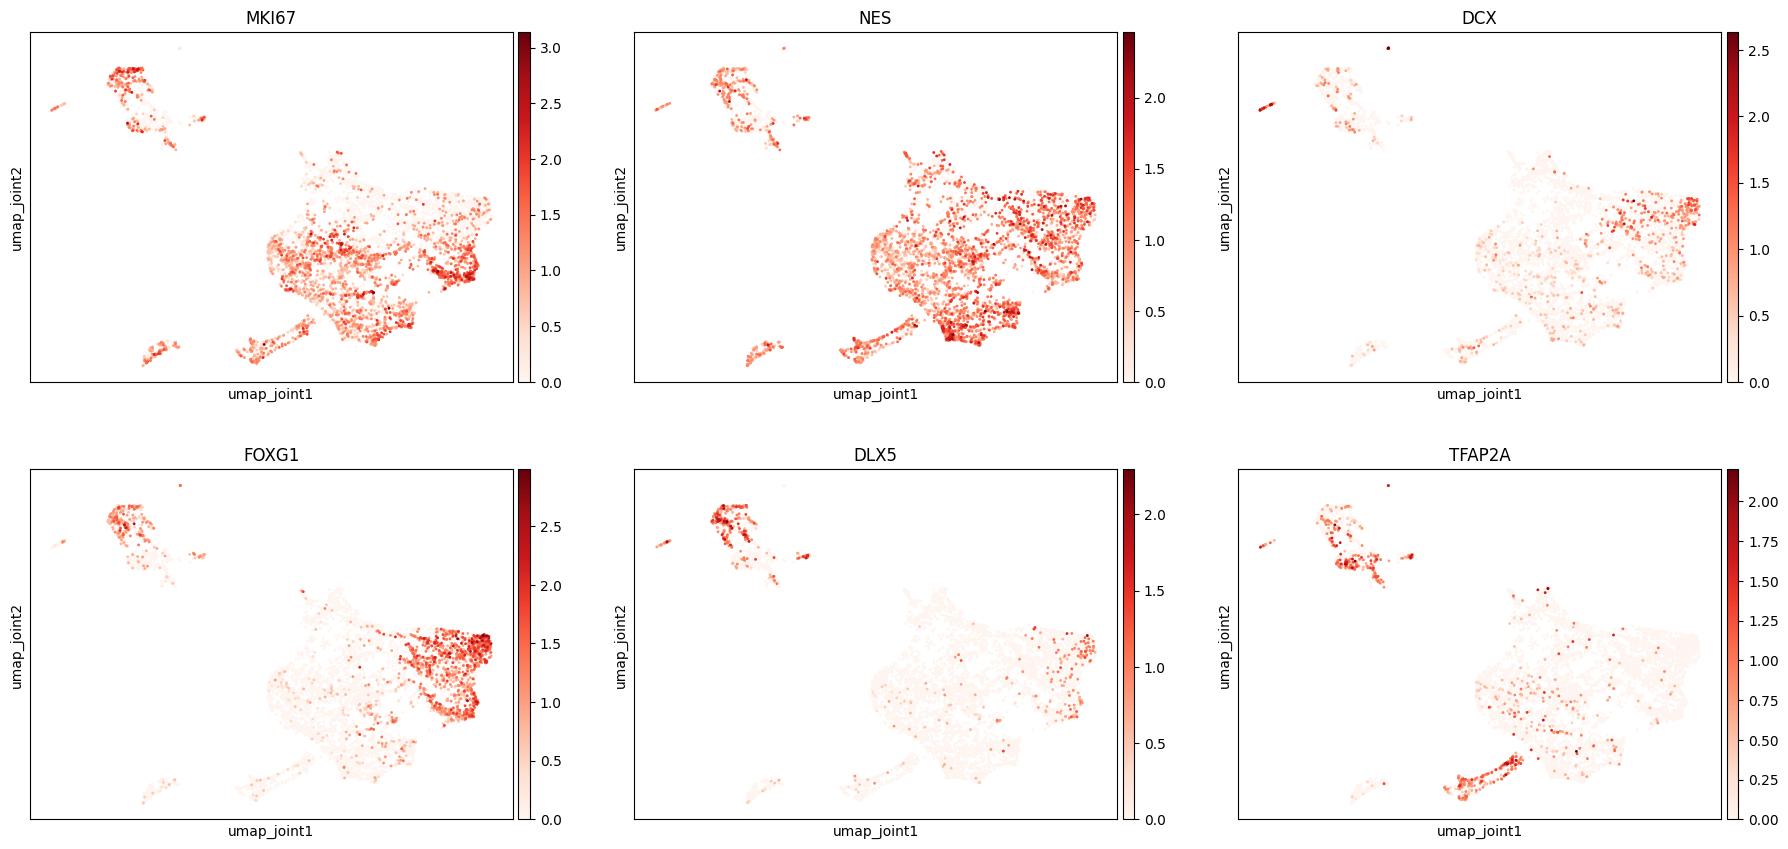

In [55]:
sc.pl.embedding(rna, basis="umap_joint", color=marker_genes, ncols=3, cmap='Reds')

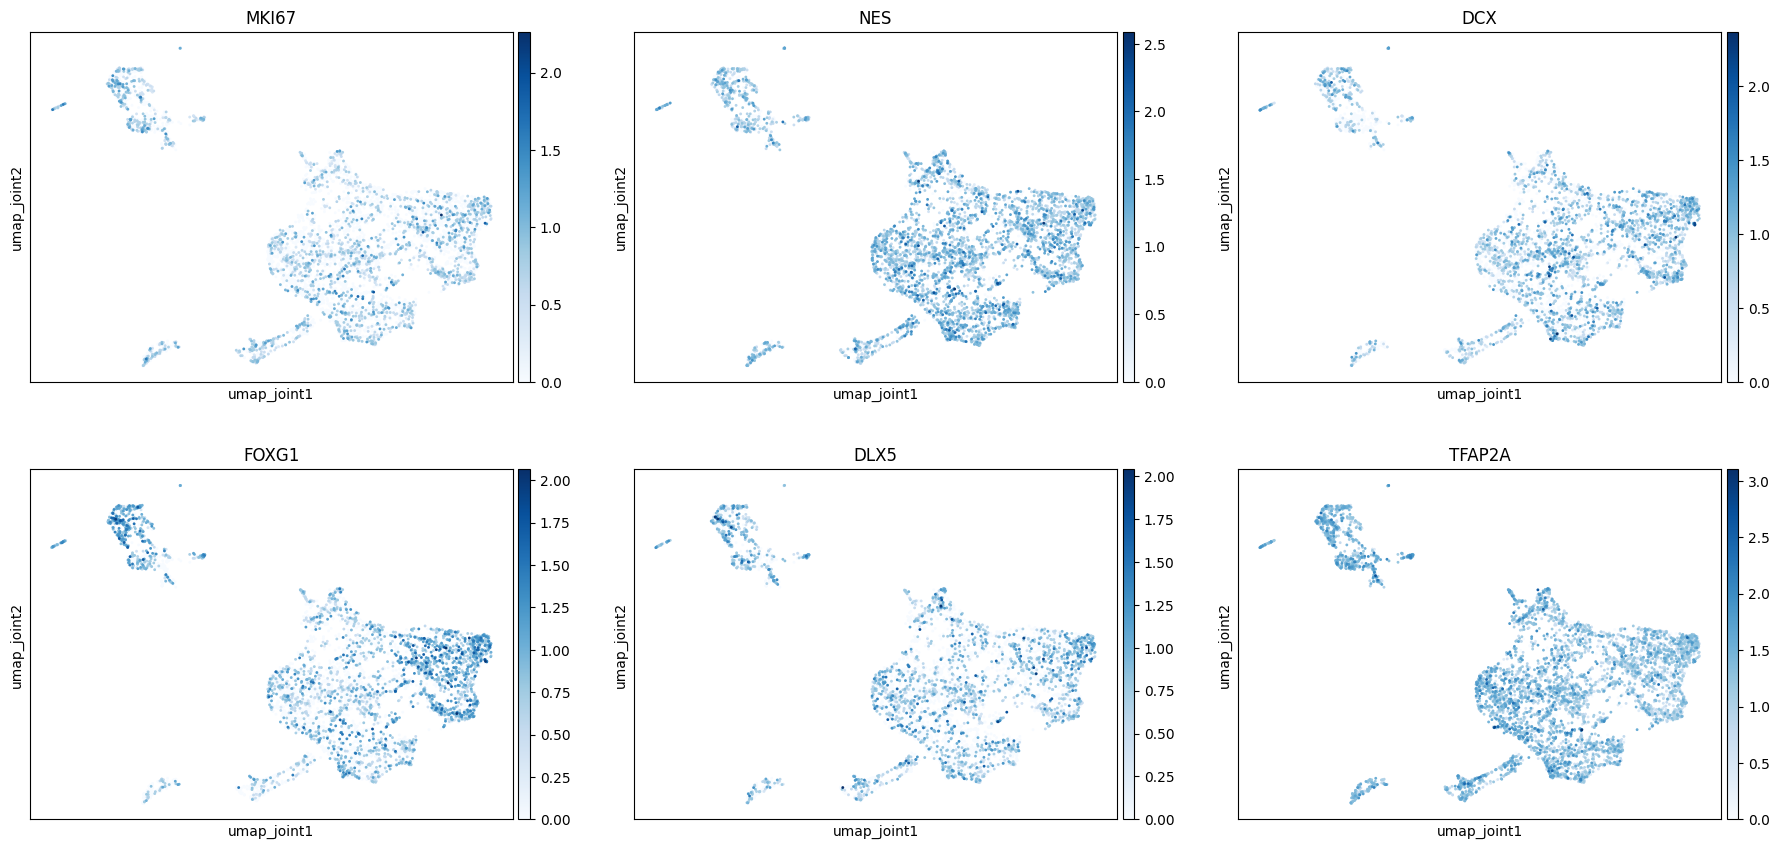

In [56]:
# and the same for ATAC
sc.pl.embedding(gene_matrix, basis="umap_joint", color=marker_genes, ncols=3, cmap='Blues')

We see that there is some correlation for ATAC openness and RNA expression (at least FOXG1, chromatin is more accessible where GEX is higher). But indeed, this is not alway the case - that's the cool part of biology!

### Step 2: Clustering and annotation with the new embedding space

In [57]:
# clustering on the joint embedding
sc.pp.neighbors(rna, n_neighbors=15, use_rep="X_joint")
sc.tl.leiden(rna, resolution=0.4, key_added="leiden_joint")

/tmp/ipykernel_3218096/587867589.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(rna, resolution=0.4, key_added="leiden_joint")


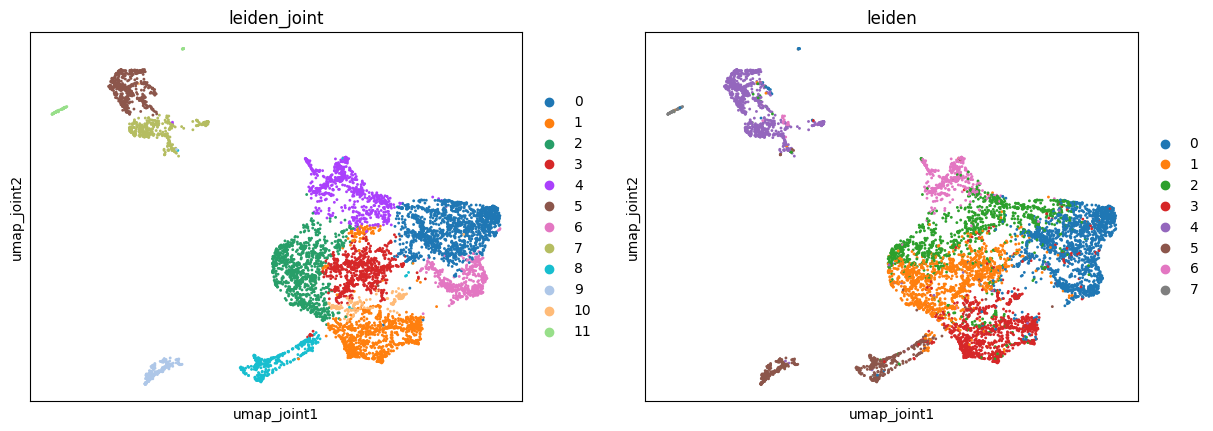

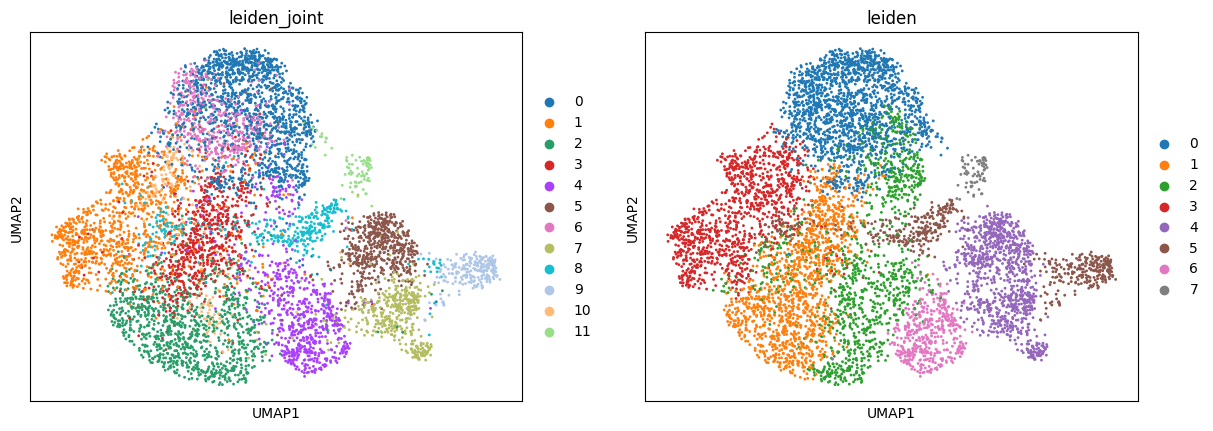

(None, None)

In [58]:
# let's plot the clustering results using joint embeddings & only RNA embeddings
sc.pl.embedding(rna, basis="umap_joint", color=["leiden_joint", "leiden"], ncols=2), sc.pl.embedding(rna, basis="umap", color=["leiden_joint", "leiden"], ncols=2)

At first glance, the two clustering results look quite similar. That’s not surprising—RNA often carries the strongest signal for cell identity, especially for broad cell types. *This is particularly true for this dataset from 3-week-old organoids, where cell type diversity is still relatively limited.*

However, when using the same clustering resolution, adding the ATAC modality can refine local structures and help separate subpopulations that RNA alone might miss. 

Let’s quantify the similarity between RNA-only and WNN clusters using a contingency table:

<Axes: xlabel='leiden_joint', ylabel='leiden'>

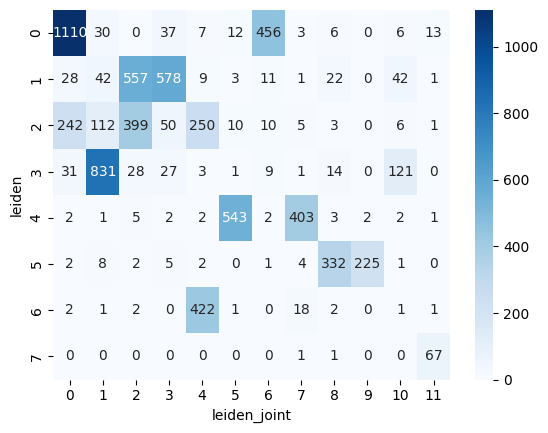

In [59]:
# compare the clustering results from the joint embedding to the clustering on the RNA data alone
df = pd.crosstab(rna.obs["leiden"], rna.obs["leiden_joint"])

# and a heatmap to visualize the overlap
import seaborn as sns
sns.heatmap(df, annot=True, fmt="d", cmap="Blues")

### Step 3: Cell type annotation

#### Option A) Single-cell flavor

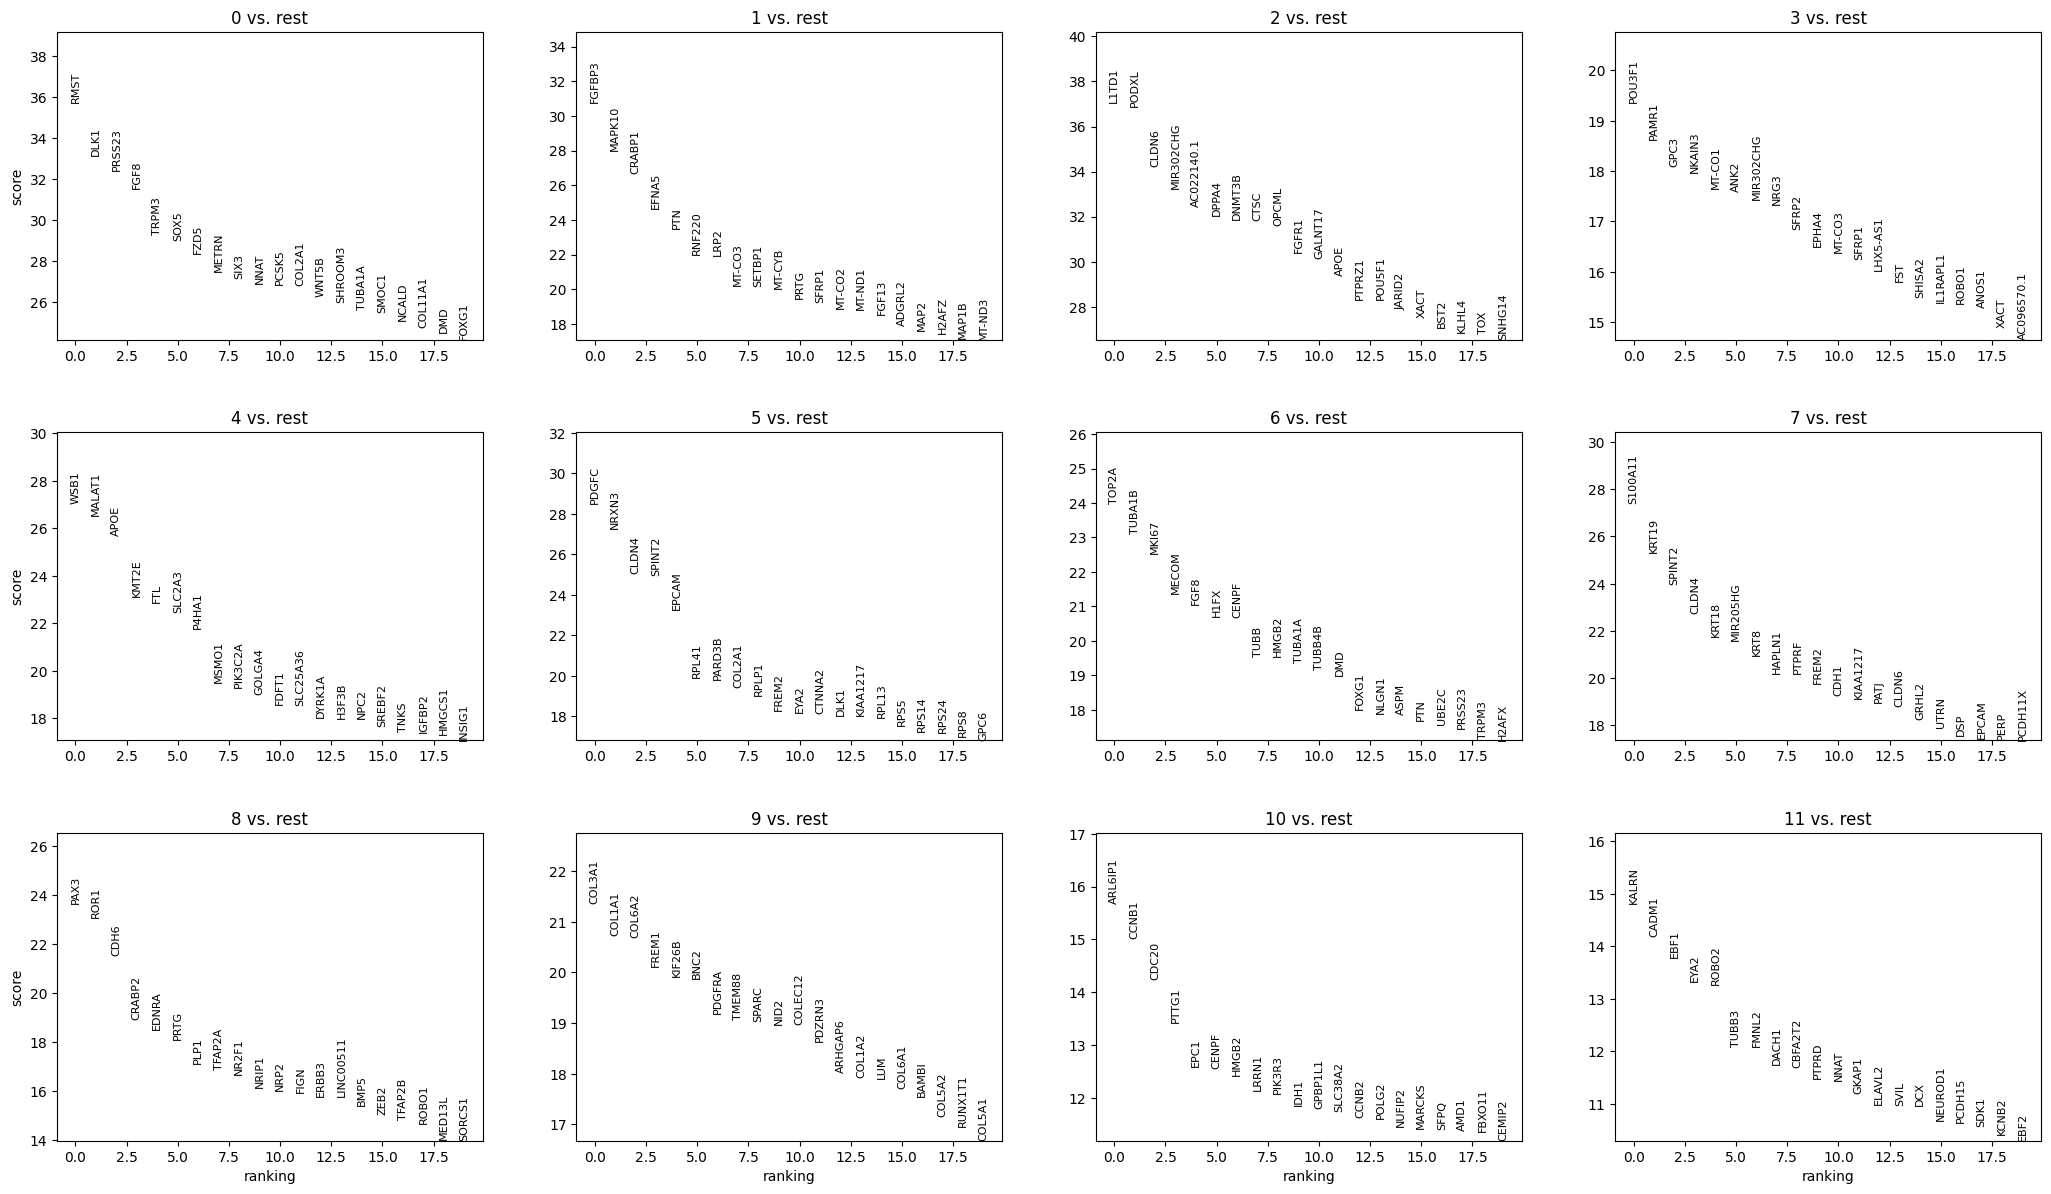

In [60]:
# single-cell flavor
sc.tl.rank_genes_groups(rna, groupby="leiden_joint", method="wilcoxon")
sc.pl.rank_genes_groups(rna, n_genes=20, sharey=False)

In [61]:
# we can also get the top DEGs per cluster
degs = pd.DataFrame(rna.uns['rank_genes_groups']['names']).head(10)
degs

,0,1,2,3,4,5,6,7,8,9,10,11
0,RMST,FGFBP3,L1TD1,POU3F1,WSB1,PDGFC,TOP2A,S100A11,PAX3,COL3A1,ARL6IP1,KALRN
1,DLK1,MAPK10,PODXL,PAMR1,MALAT1,NRXN3,TUBA1B,KRT19,ROR1,COL1A1,CCNB1,CADM1
2,PRSS23,CRABP1,CLDN6,GPC3,APOE,CLDN4,MKI67,SPINT2,CDH6,COL6A2,CDC20,EBF1
3,FGF8,EFNA5,MIR302CHG,NKAIN3,KMT2E,SPINT2,MECOM,CLDN4,CRABP2,FREM1,PTTG1,EYA2
4,TRPM3,PTN,AC022140.1,MT-CO1,FTL,EPCAM,FGF8,KRT18,EDNRA,KIF26B,EPC1,ROBO2
5,SOX5,RNF220,DPPA4,ANK2,SLC2A3,RPL41,H1FX,MIR205HG,PRTG,BNC2,CENPF,TUBB3
6,FZD5,LRP2,DNMT3B,MIR302CHG,P4HA1,PARD3B,CENPF,KRT8,PLP1,PDGFRA,HMGB2,FMNL2
7,METRN,MT-CO3,CTSC,NRG3,MSMO1,COL2A1,TUBB,HAPLN1,TFAP2A,TMEM88,LRRN1,DACH1
8,SIX3,SETBP1,OPCML,SFRP2,PIK3C2A,RPLP1,HMGB2,PTPRF,NR2F1,SPARC,PIK3R3,CBFA2T2
9,NNAT,MT-CYB,FGFR1,EPHA4,GOLGA4,FREM2,TUBA1A,FREM2,NRIP1,NID2,IDH1,PTPRD


#### Option B) Curated markers

In [62]:
# alternatively, we can annotate them using a curated marker genes
markers = pd.read_csv("markers.txt", sep="\t")
# change index into 'gene' for easier access
markers['gene'] = markers.index
# filter for the marker genes that are present in our dataset
markers = markers[markers['gene'].isin(rna.var_names)]
markers

,level1,level2,level3,level4,level5,gene
SOX2,neural_progenitor_cell,NaN,NaN,NaN,NaN,SOX2
VIM,neural_progenitor_cell,NaN,NaN,NaN,NaN,VIM
NES,neural_progenitor_cell,NaN,NaN,NaN,NaN,NES
HOPX,neural_progenitor_cell,glioblast,NaN,NaN,NaN,HOPX
BCAN,neural_progenitor_cell,glioblast,NaN,NaN,NaN,BCAN
TNC,neural_progenitor_cell,glioblast,NaN,NaN,NaN,TNC
FOXG1,neural_progenitor_cell,telencephalic_npc,NaN,NaN,NaN,FOXG1
EMX1,neural_progenitor_cell,telencephalic_npc,dorsal_npc,NaN,NaN,EMX1
GABRA2,neural_progenitor_cell,telencephalic_npc,hippocampal_npc,NaN,NaN,GABRA2
GABRB1,neural_progenitor_cell,telencephalic_npc,hippocampal_npc,NaN,NaN,GABRB1


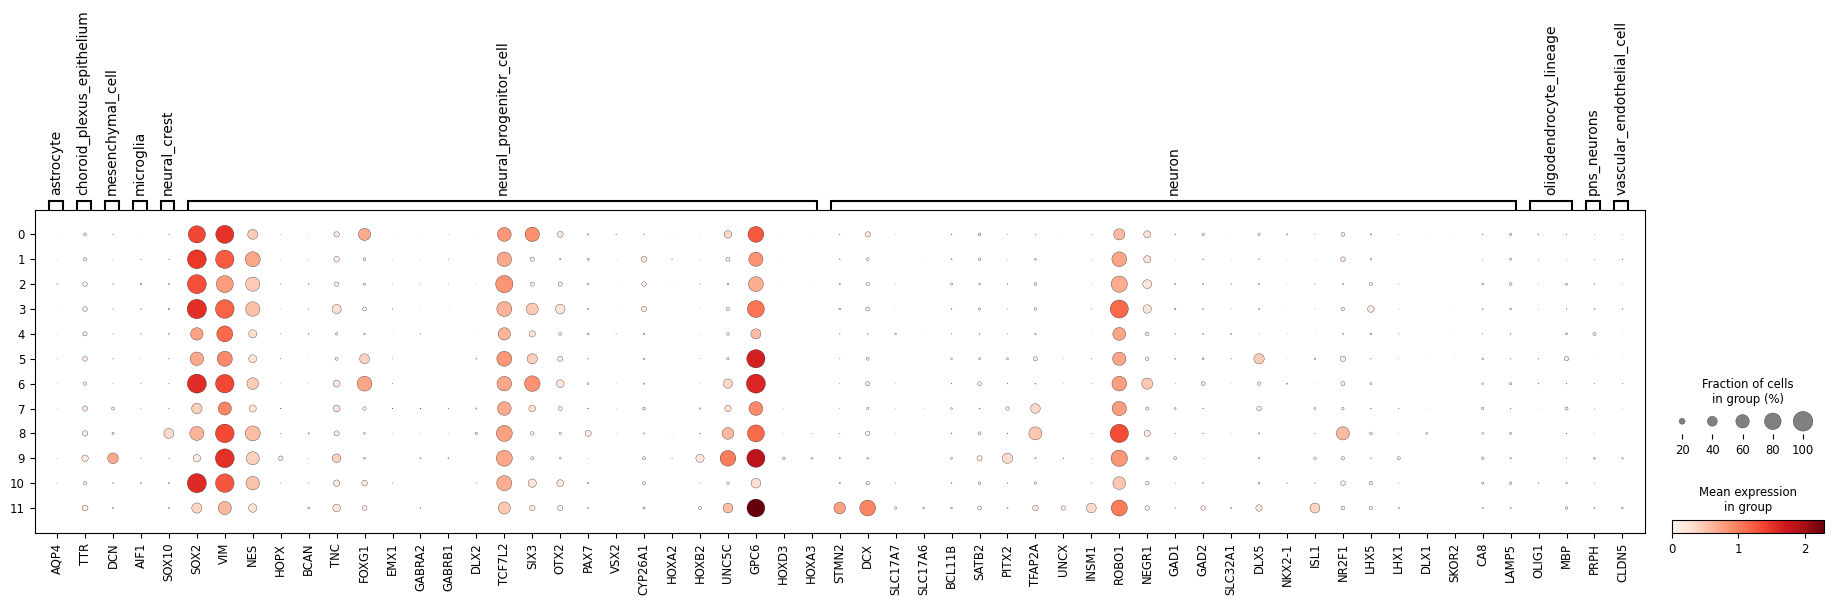

In [63]:
# using the first level of annotation
# convert into a dict to group the marker genes by cell type
markers_dict = markers.groupby("level1")["gene"].apply(list).to_dict()
sc.pl.dotplot(rna, markers_dict, groupby="leiden_joint")

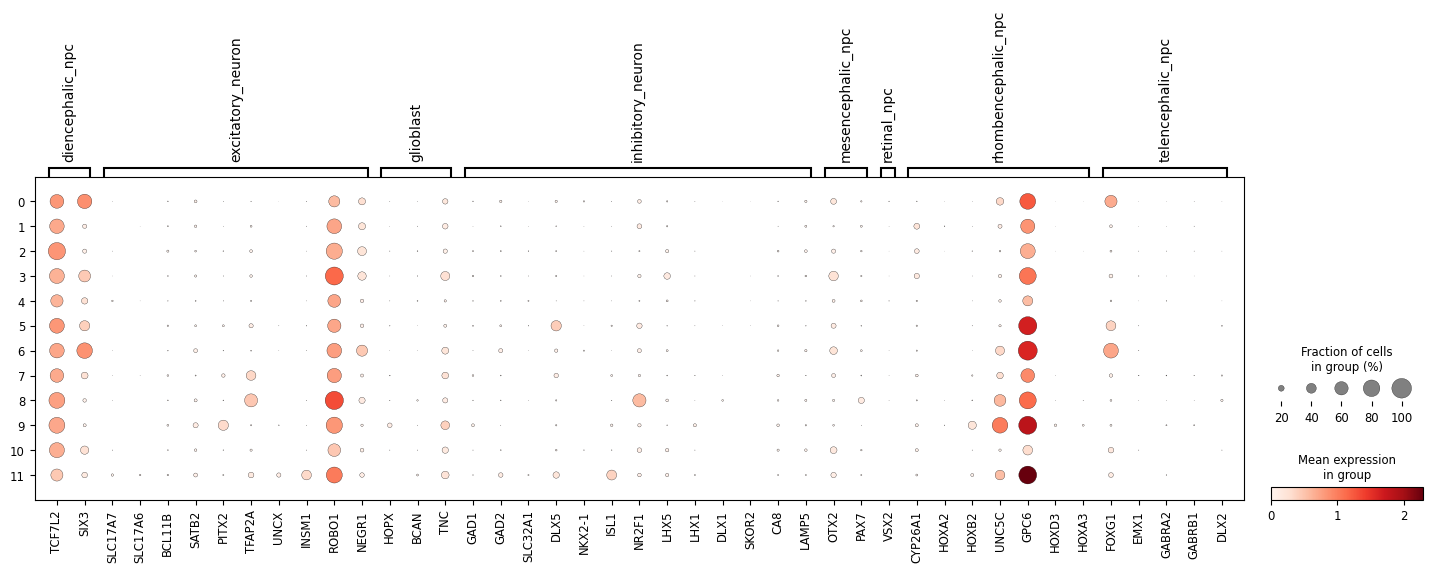

In [64]:
# also try the 2nd level of annotation
markers_dict = markers.groupby("level2")["gene"].apply(list).to_dict()
sc.pl.dotplot(rna, markers_dict, groupby="leiden_joint")

#### Option C) Pseudobulk 

In [65]:
# Aggregate gene expression per cluster
rna_avg = sc.get.aggregate(rna, by=['leiden_joint'], func=['mean'])
rna_avg

AnnData object with n_obs × n_vars = 12 × 26885
    obs: 'leiden_joint', 'n_obs_aggregated'
    var: 'feature', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    layers: 'mean'

In [67]:
# get the mean layer and make it into a dataframe for easier access
rna_avg_df = pd.DataFrame(rna_avg.layers["mean"], index=rna_avg.obs_names, columns=rna_avg.var_names)

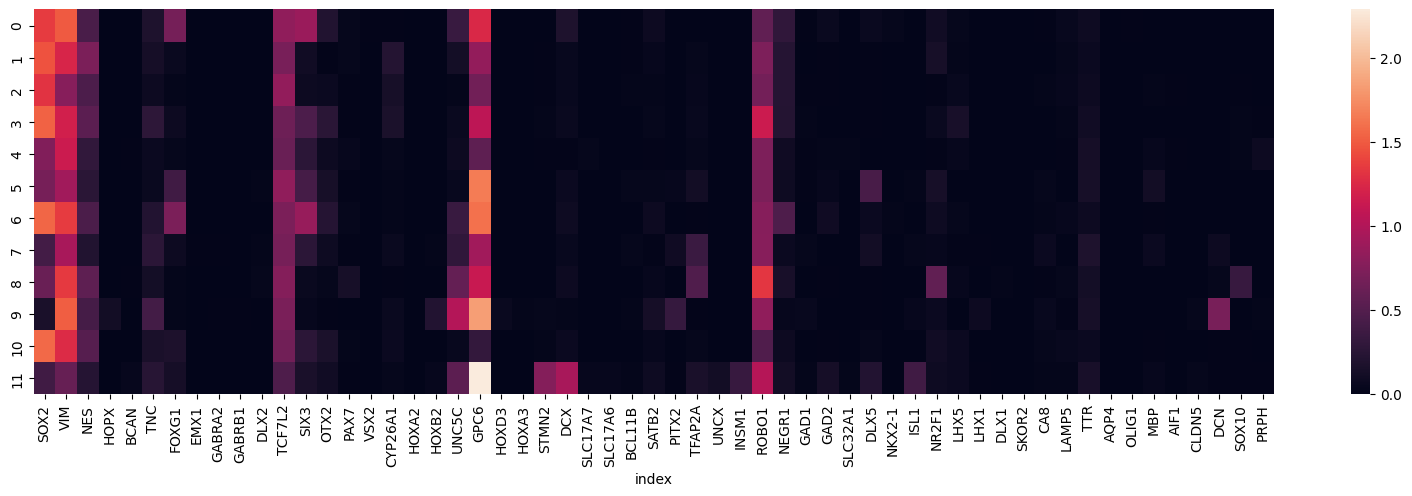

In [68]:
# plot the marker gene expression in the aggregated data
level1_markers = markers[markers['level1'].notna()]['gene']
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 5))
sns.heatmap(rna_avg_df[level1_markers])
plt.show()

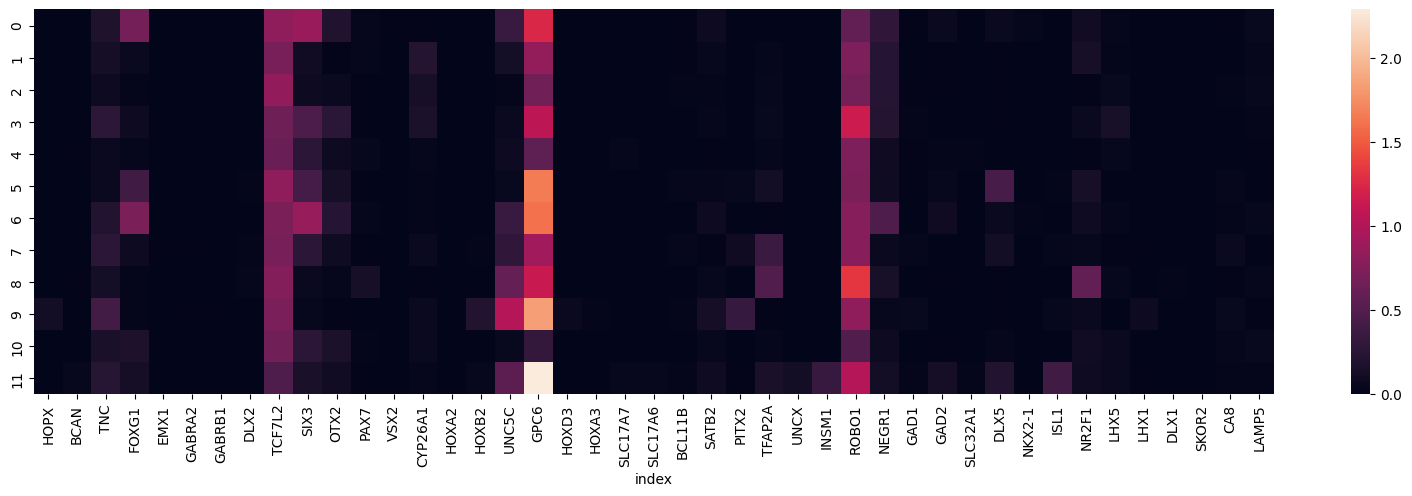

In [69]:
# also level 2 markers
level2_markers = markers[markers['level2'].notna()]['gene']
plt.figure(figsize=(20, 5))
sns.heatmap(rna_avg_df[level2_markers])
plt.show()

... storing 'leiden_joint_annot' as categorical


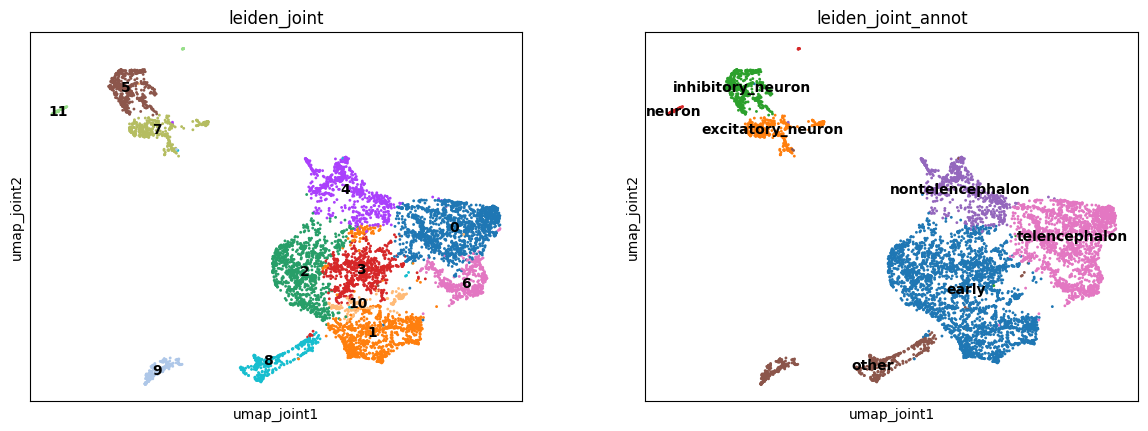

In [70]:
# give very coarse annotations based on the first level of annotation
rna.obs["leiden_joint_annot"] = rna.obs["leiden_joint"].map({
    "0": "telencephalon",
    "1": "early",
    "2": "early",
    "3": "early",
    "4": "nontelencephalon",
    "5": "inhibitory_neuron",
    "6": "telencephalon",
    "7": "excitatory_neuron",
    "8": "other",
    "9": "other",
    "10": "early",
    "11": "neuron",
})
sc.pl.embedding(rna, basis="umap_joint", color=["leiden_joint", "leiden_joint_annot"], legend_loc="on data", ncols=2)

## Part 4: KO vs WT

### Step 1 : Differentially Expressed Genes
#### Option A) Single cell flavor

In [71]:
pd.crosstab(rna.obs["leiden_joint_annot"], rna.obs["sample"])

sample,KO1,KO2,WT
leiden_joint_annot,,,
early,1055,805,1036
excitatory_neuron,95,296,45
inhibitory_neuron,164,311,95
neuron,17,41,26
nontelencephalon,122,234,339
other,65,424,121
telencephalon,963,410,533


In [72]:
# we subset the data to only include the telencephalon clusters and check the DEGs between WT and KO samples
rna_subset = rna[rna.obs["leiden_joint_annot"] == "telencephalon", :]
# group KO1 and KO2 together as 'KO' for the DE analysis
rna_subset.obs["group"] = rna_subset.obs["sample"].map({"WT": "WT", "KO1": "KO", "KO2": "KO"})
# have a look at the groups
rna_subset.obs["group"].value_counts()

/tmp/ipykernel_3218096/4282709727.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  rna_subset.obs["group"] = rna_subset.obs["sample"].map({"WT": "WT", "KO1": "KO", "KO2": "KO"})


group
KO    1373
WT     533
Name: count, dtype: int64

... storing 'group' as categorical


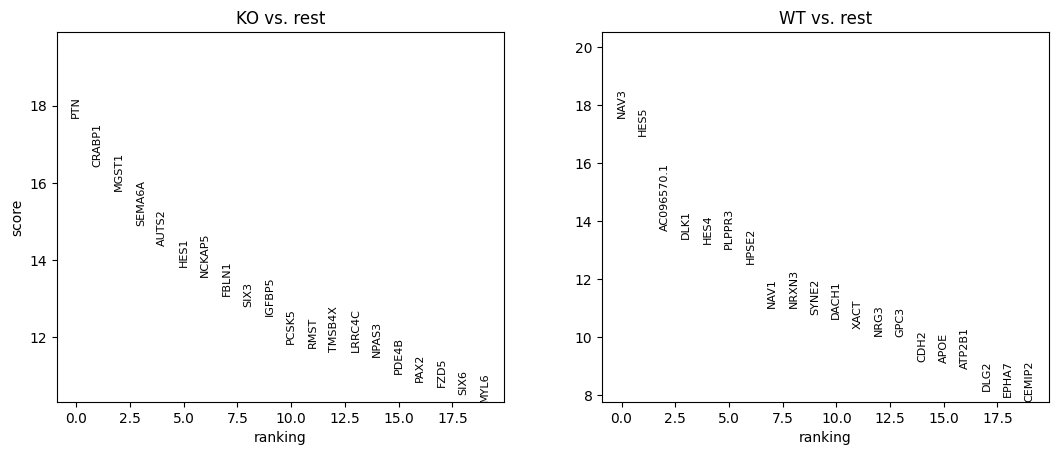

In [73]:
# single cell flavor
sc.tl.rank_genes_groups(rna_subset, groupby="group", method="wilcoxon")
sc.pl.rank_genes_groups(rna_subset, n_genes=20, sharey=False)

#### Option B) Pseudobulk flavor

Here we use the python implementation of the classic DESeq2: [PyDESeq2](https://pydeseq2.readthedocs.io/en/stable/auto_examples/plot_minimal_pydeseq2_pipeline.html#single-factor-analysis)

In [74]:
# DESeq2 related
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

In [75]:
# bulk flavor: aggregate gene expression per group and then do DE analysis on the aggregated data
rna_subset_pseudo = sc.get.aggregate(rna_subset, layer='counts',by=['sample'], func=['sum']) #PyDeseq2 wants raw counts, so we use sum here instead of mean
rna_subset_pseudo

AnnData object with n_obs × n_vars = 3 × 26885
    obs: 'sample', 'n_obs_aggregated'
    var: 'feature', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    layers: 'sum'

In [76]:
# sanity check - should be a count matrix
rna_subset_pseudo.layers['sum'][:5, :5]

array([[ 3.,  7.,  0.,  0., 83.],
       [ 3.,  3.,  0.,  2., 42.],
       [ 0.,  5.,  0.,  0., 35.]])

In [77]:
rna_subset_pseudo.obs['condition'] = rna_subset_pseudo.obs_names.map({"WT": "WT", "KO1": "KO", "KO2": "KO"})
rna_subset_pseudo.obs

,sample,n_obs_aggregated,condition
KO1,KO1,963,KO
KO2,KO2,410,KO
WT,WT,533,WT


In [78]:
dds = DeseqDataSet(
        counts=rna_subset_pseudo.layers['sum'], # count data
        metadata=rna_subset_pseudo.obs, # metadata
        design="~condition", # column in the metadata that contains the condition information
    )
# add var_names to the dds object for easier interpretation of results
dds.var_names = rna_subset_pseudo.var_names

dds

AnnData object with n_obs × n_vars = 3 × 26885
    obs: 'sample', 'n_obs_aggregated', 'condition'
    obsm: 'design_matrix'

In [79]:
# run DESeq2
dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.15 seconds.

Fitting dispersion trend curve...
... done in 0.34 seconds.

/work/upzenk/miniconda3/envs/scMultiome/lib/python3.13/site-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 1.27 seconds.

Fitting LFCs...
... done in 1.48 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [80]:
ds = DeseqStats(dds, contrast=['condition', 'KO', 'WT'])
ds.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: condition KO vs WT
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
index                                                                        
AL627309.1   1.991936        3.828217  4.329072  0.884304  0.376532       NaN
AL627309.5   4.730774       -0.387884  1.865213 -0.207957  0.835263       NaN
AL627309.4   0.000000             NaN       NaN       NaN       NaN       NaN
AL669831.2   0.896368        2.642186  5.600586  0.471770  0.637091       NaN
LINC01409   49.864296        0.482612  0.661270  0.729825  0.465497  0.999992
...               ...             ...       ...       ...       ...       ...
AC011841.1   4.372237       -0.088022  1.955394 -0.045015  0.964095       NaN
AL592183.1  33.796153        0.378445  0.773241  0.489426  0.624540       NaN
AC240274.1  36.113272       -0.249345  0.744576 -0.334882  0.737714       NaN
AC007325.4   3.997105        0.328608  2.063141  0.159276  0.873452       NaN
AC00732

... done in 1.29 seconds.



In [81]:
df = ds.results_df.sort_values('padj')
df.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
index,,,,,,
HES5,407.876943,-3.744958,0.374143,-10.009437,1.385388e-23,1.237982e-19
HES4,178.693163,-3.955386,0.511124,-7.738600,1.005177e-14,4.491129e-11
PAX2,233.043257,3.766914,0.494683,7.614800,2.641002e-14,7.866663e-11
NAV3,869.328763,-2.140164,0.330059,-6.484184,8.921345e-11,1.993029e-07
EMX2,61.495325,-4.309398,0.693734,-6.211891,5.235067e-10,9.356112e-07


In [82]:
# slice out the significant DEGs
sig_degs = df[df['padj'] < 0.05]
sig_degs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
index,,,,,,
HES5,407.876943,-3.744958,0.374143,-10.009437,1.385388e-23,1.237982e-19
HES4,178.693163,-3.955386,0.511124,-7.738600,1.005177e-14,4.491129e-11
PAX2,233.043257,3.766914,0.494683,7.614800,2.641002e-14,7.866663e-11
NAV3,869.328763,-2.140164,0.330059,-6.484184,8.921345e-11,1.993029e-07
EMX2,61.495325,-4.309398,0.693734,-6.211891,5.235067e-10,9.356112e-07
PLPPR3,153.088315,-3.106634,0.514437,-6.038905,1.551635e-09,2.310902e-06
AC096570.1,406.266055,-2.403077,0.400843,-5.995059,2.034111e-09,2.596688e-06
XACT,595.025008,-1.851442,0.345689,-5.355801,8.517800e-08,9.514382e-05
NR2F2-AS1,217.820906,2.499460,0.475212,5.259677,1.443083e-07,1.432821e-04


### Step 2 : Differentially accesible regions

In [93]:
# we can do the same DE analysis for the atac dataset, but here we look for differentially accessible peaks instead of genes

# subset to telencephalon clusters as well
atac_subset = atac[rna_subset.obs_names, :]
atac_subset

View of AnnData object with n_obs × n_vars = 1906 × 52651
    obs: 'batch', 'sample', 'n_peaks_by_reads', 'total_reads', 'leiden'
    var: 'feature', 'feature_types', 'n_cells_by_reads', 'mean_reads', 'pct_dropout_by_reads', 'total_reads', 'count', 'selected'
    uns: 'sample_colors', 'spectral_eigenvalue', 'neighbors', 'leiden', 'leiden_colors'
    obsm: 'X_spectral', 'X_umap', 'X_joint', 'X_umap_joint'
    obsp: 'distances', 'connectivities'

In [94]:
# group KO1 and KO2 together as 'KO' for the DE analysis
atac_subset.obs["group"] = atac_subset.obs["sample"].map({"WT": "WT", "KO1": "KO", "KO2": "KO"})
# have a look at the groups
atac_subset.obs["group"].value_counts()

/tmp/ipykernel_3218096/2084590599.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  atac_subset.obs["group"] = atac_subset.obs["sample"].map({"WT": "WT", "KO1": "KO", "KO2": "KO"})


group
KO    1373
WT     533
Name: count, dtype: int64

... storing 'group' as categorical


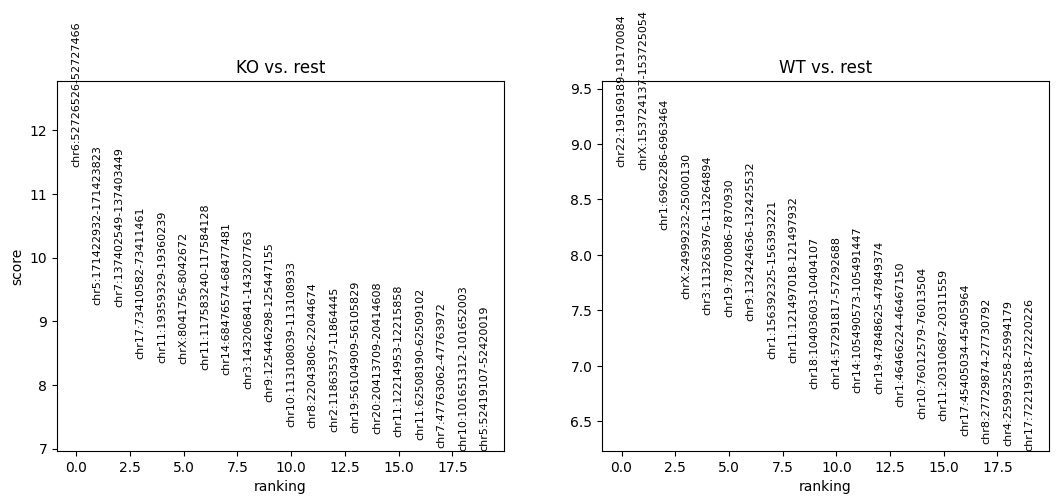

In [95]:
# single cell flavor
sc.tl.rank_genes_groups(atac_subset, groupby="group", method="wilcoxon")
sc.pl.rank_genes_groups(atac_subset, n_genes=20, sharey=False)

In [119]:
# get the DARs and filter for significant DARs (e.g. adjusted p-value < 0.05)
dar_df_ko = sc.get.rank_genes_groups_df(atac_subset, group="KO")
dar_sig_ko = dar_df_ko[dar_df_ko["pvals_adj"] < 0.05]
dar_sig_ko.head(5)

,names,scores,logfoldchanges,pvals,pvals_adj
0,chr6:52726526-52727466,11.433554,3.206047,2.842329e-30,1.496515e-25
1,chr5:171422932-171423823,9.253676,2.391559,2.169011e-20,4.598619e-16
2,chr7:137402549-137403449,9.233461,2.412102,2.620246e-20,4.598619e-16
3,chr17:73410582-73411461,8.415312,2.416381,3.918510e-17,3.438558e-13
4,chr11:19359329-19360239,8.354435,2.971727,6.574655e-17,4.873376e-13


In [120]:
# same for group "WT"
dar_df_wt = sc.get.rank_genes_groups_df(atac_subset, group="WT")
dar_sig_wt = dar_df_wt[dar_df_wt["pvals_adj"] < 0.05]
dar_sig_wt.head(5)

,names,scores,logfoldchanges,pvals,pvals_adj
0,chr22:19169189-19170084,8.798144,2.418324,1.390971e-18,1.830901e-14
1,chrX:153724137-153725054,8.767636,1.815898,1.824560e-18,1.921298e-14
2,chr1:6962286-6963464,8.226469,1.882117,1.928131e-16,1.015180e-12
3,chrX:24999232-25000130,7.606528,2.852713,2.815573e-14,1.058877e-10
4,chr3:113263976-113264894,7.456539,2.027828,8.882512e-14,3.117821e-10


### Step 3 : Plot the accessibilty 

In [83]:
# we copy over the atac.obs to the frag.obs to make sure they are the same and we can use the same cell barcodes for both datasets
frag.obs = atac.obs.copy()
frag

AnnData object with n_obs × n_vars = 7197 × 0
    obs: 'batch', 'sample', 'n_peaks_by_reads', 'total_reads', 'leiden'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

In [84]:
import gzip
with gzip.open(snap.genome.hg38.annotation, 'rt') as f:
     gff = pd.read_csv(f, sep='\t', comment='#', header=None,
                      names=['chrom','source','feature','start','end','score','strand','frame','attributes'])
genes = gff[gff['feature'] == 'gene']


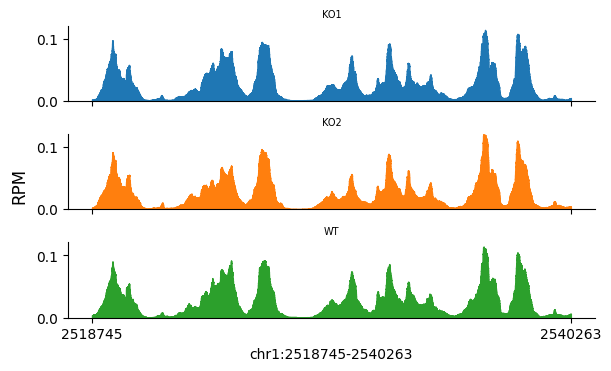

In [91]:
gene = genes[genes['attributes'].str.contains('HES5')]
chrom, start, end = gene['chrom'].values[0], gene['start'].values[0], gene['end'].values[0]
region = f"{chrom}:{start - 10000}-{end + 10000}" # eg. chr3: 155508000-155518000
snap.pl.coverage(frag, region=region, groupby='sample')  

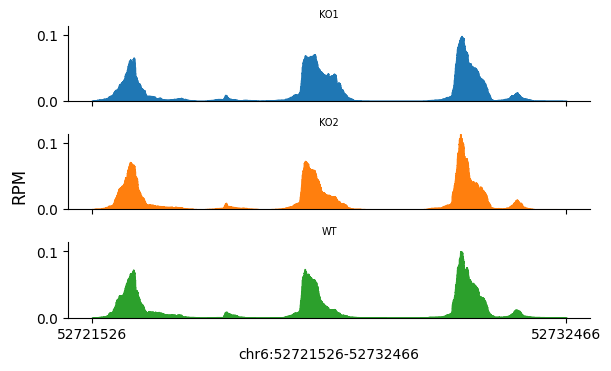

In [121]:
# do the same for a differentially accessible peak, e.g. the top DAR in cluster 0
top_dar = dar_sig_ko.iloc[0, 0] # get the top DAR 
# extend the peak region by 1000bp on each side for better visualization
chrom, start, end = top_dar.split(":")[0], int(top_dar.split(":")[1].split("-")[0]), int(top_dar.split(":")[1].split("-")[1])
region = f"{chrom}:{start - 5000}-{end + 5000}"
snap.pl.coverage(frag, region=region, groupby='sample')

### Step 4: Motif analysis 

Here we just use what [SnapATAC2](https://scverse.org/SnapATAC2/version/2.9/api/_autosummary/snapatac2.tl.motif_enrichment.html) implemented as a quick and dirty way for motif analysis. Since we did not provide a proper background regions, the results are not interpretable. 

But rather, we here just to show that it is possible to follow this [tutorial](https://scverse.org/SnapATAC2/version/2.9/tutorials/diff.html#Finding-marker-regions).

In [122]:
%%time
motifs = snap.tl.motif_enrichment(
    motifs=snap.datasets.cis_bp(unique=True),
    regions={'KO_DAR':dar_sig_ko['names'],
             'WT_DAR':dar_sig_wt['names']},
    genome_fasta=snap.genome.hg38,
)

2026-04-09 15:34:56 - INFO - Fetching 985 sequences ...
2026-04-09 15:35:36 - INFO - Computing enrichment ...
100%|██████████| 1165/1165 [00:36<00:00, 31.89it/s]

CPU times: user 1min 55s, sys: 8.23 s, total: 2min 3s
Wall time: 1min 16s


In [133]:
motifs["KO_DAR"].sort("adjusted p-value", descending=False).head()

id,name,family,log2(fold change),p-value,adjusted p-value
str,str,null,f64,f64,f64
"""AC023509.3+M02872_2.00""","""AC023509.3""",null,0.0,1.0,1.0
"""AC138696.1+M04597_2.00""","""AC138696.1""",null,0.0,1.0,1.0
"""AHR+M09817_2.00""","""AHR""",null,0.0,1.0,1.0
"""AIRE+M09375_2.00""","""AIRE""",null,0.0,1.0,1.0
"""ALX1+M05327_2.00""","""ALX1""",null,0.0,1.0,1.0


In [134]:
motifs["WT_DAR"].sort("adjusted p-value", descending=False).head()

id,name,family,log2(fold change),p-value,adjusted p-value
str,str,null,f64,f64,f64
"""AC023509.3+M02872_2.00""","""AC023509.3""",null,0.0,1.0,1.0
"""AC138696.1+M04597_2.00""","""AC138696.1""",null,0.0,1.0,1.0
"""AHR+M09817_2.00""","""AHR""",null,0.0,1.0,1.0
"""AIRE+M09375_2.00""","""AIRE""",null,0.0,1.0,1.0
"""ALX1+M05327_2.00""","""ALX1""",null,0.0,1.0,1.0
